In [ ]:
# Berlin Food Delivery ETA Prediction
## Modelling — Baseline Models

Goal: Train and evaluate baseline regression models before moving to ensembles.
Since `test.csv` has no target column (it's for a final Kaggle-style submission), 
we'll carve out our own validation set from the training data to evaluate models properly.

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)

In [33]:
train = pd.read_csv('train_features.csv')
test = pd.read_csv('test_features.csv')

print(train.shape, test.shape)
train.head()

(45593, 37) (11399, 36)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,multiple_deliveries,Time_taken(min),distance_km,order_hour,day_of_week,is_weekend,is_rush_hour,prep_time_min,traffic_level_num,distance_x_traffic,is_bad_weather,berlin_temp_c,berlin_precip_mm,berlin_windspeed_max,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,City_Semi-Urban,City_Urban,Festival_Yes
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,2,0.0,24.0,3.025149,11.0,5,1,0,15.0,3,9.075448,0,5.4,0.2,24.3,False,False,True,False,True,False,False,True,False
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,2,1.0,33.0,20.183530,19.0,4,0,1,5.0,4,80.734119,1,7.8,0.0,13.6,False,False,True,False,False,True,False,False,False
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,0,1.0,26.0,1.552758,8.0,5,1,0,15.0,1,1.552758,1,5.4,0.2,24.3,True,False,False,False,True,False,False,True,False
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,0,1.0,21.0,7.790401,18.0,1,0,0,10.0,2,15.580803,0,6.4,4.1,31.9,False,False,False,False,True,False,False,False,False
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,1,1.0,30.0,6.210138,13.0,5,1,1,15.0,3,18.630414,0,7.9,0.1,21.9,False,False,True,False,False,True,False,False,False


In [34]:
## Dropped columns not required in my model

# IDs, raw datetime/text fields already converted into engineered features, 
# and raw lat/long (superseded by distance_km) should not be fed to the model directly

drop_cols = [
    'ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked',
    'Restaurant_latitude', 'Restaurant_longitude', 
    'Delivery_location_latitude', 'Delivery_location_longitude',
    'Weatherconditions', 'Road_traffic_density'  # already captured via is_bad_weather / traffic_level_num
]

X = train.drop(columns=drop_cols + ['Time_taken(min)'])
y = train['Time_taken(min)']

X_test_final = test.drop(columns=[c for c in drop_cols if c in test.columns])

print(X.shape, y.shape, X_test_final.shape)
print(X.columns.tolist())

(45593, 25) (45593,) (11399, 25)
['Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'multiple_deliveries', 'distance_km', 'order_hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'prep_time_min', 'traffic_level_num', 'distance_x_traffic', 'is_bad_weather', 'berlin_temp_c', 'berlin_precip_mm', 'berlin_windspeed_max', 'Type_of_order_Drinks', 'Type_of_order_Meal', 'Type_of_order_Snack', 'Type_of_vehicle_electric_scooter', 'Type_of_vehicle_motorcycle', 'Type_of_vehicle_scooter', 'City_Semi-Urban', 'City_Urban', 'Festival_Yes']


In [35]:
## Checking for remaining Non-Numeric Columns

print(X.dtypes.value_counts())
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric columns remaining:", non_numeric)

float64    10
bool        9
int64       6
Name: count, dtype: int64
Non-numeric columns remaining: ['Type_of_order_Drinks', 'Type_of_order_Meal', 'Type_of_order_Snack', 'Type_of_vehicle_electric_scooter', 'Type_of_vehicle_motorcycle', 'Type_of_vehicle_scooter', 'City_Semi-Urban', 'City_Urban', 'Festival_Yes']


In [36]:
## train/split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)

(36474, 25) (9119, 25)


In [37]:
## Helper Function to evaluate any model consistently

def evaluate_model(name, model, X_val, y_val):
    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)
    print(f"{name} -> MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f}")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []

In [38]:
## model 1: Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate_model('Linear Regression', lr, X_val, y_val))

Linear Regression -> MAE: 5.103 | RMSE: 6.443 | R²: 0.527


In [39]:
nan_summary = X.isnull().sum()
print(nan_summary[nan_summary > 0])
print()
print("Total NaNs in X:", X.isnull().sum().sum())

Series([], dtype: int64)

Total NaNs in X: 0


In [40]:
print(X.isnull().sum().sum())
weather_cols = ['berlin_temp_c', 'berlin_precip_mm', 'berlin_windspeed_max']
print(X[weather_cols].isnull().sum())

0
berlin_temp_c           0
berlin_precip_mm        0
berlin_windspeed_max    0
dtype: int64


In [41]:
## model 2: Decision Tree
dt = DecisionTreeRegressor(random_state=42, max_depth=8)
dt.fit(X_train, y_train)
results.append(evaluate_model('Decision Tree', dt, X_val, y_val))

Decision Tree -> MAE: 4.297 | RMSE: 5.455 | R²: 0.661


In [42]:
## model comparison

results_df = pd.DataFrame(results)
results_df

,model,MAE,RMSE,R2
0,Linear Regression,5.103365,6.442980,0.526541
1,Decision Tree,4.297159,5.455078,0.660601


In [43]:
## Checking Again

train_preds = dt.predict(X_train)
train_mae = mean_absolute_error(y_train, train_preds)
train_r2 = r2_score(y_train, train_preds)
print(f"Decision Tree (train) -> MAE: {train_mae:.3f} | R²: {train_r2:.3f}")

Decision Tree (train) -> MAE: 4.263 | R²: 0.663


In [ ]:
## Ensemble Methods

Baselines confirmed working with no overfitting. Now applying ensemble methods 
(Random Forest, Gradient Boosting) to capture feature interactions more effectively 
than a single tree.

In [44]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [45]:
## Random Forest

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model('Random Forest', rf, X_val, y_val))

Random Forest -> MAE: 4.211 | RMSE: 5.325 | R²: 0.677


In [50]:
## Gradient Boosting

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model('Random Forest', rf, X_val, y_val))

Random Forest -> MAE: 4.211 | RMSE: 5.325 | R²: 0.677


In [51]:
## Comparing All models

results_df = pd.DataFrame(results)
results_df.sort_values('R2', ascending=False)

,model,MAE,RMSE,R2
2,Random Forest,4.211176,5.324904,0.676606
3,Random Forest,4.211176,5.324904,0.676606
4,Random Forest,4.211176,5.324904,0.676606
1,Decision Tree,4.297159,5.455078,0.660601
0,Linear Regression,5.103365,6.442980,0.526541


In [52]:
## Remove duplicate entries, keep only unique model results
results_df = pd.DataFrame(results).drop_duplicates(subset='model', keep='last')
print(results_df)

               model       MAE      RMSE        R2
0  Linear Regression  5.103365  6.442980  0.526541
1      Decision Tree  4.297159  5.455078  0.660601
4      Random Forest  4.211176  5.324904  0.676606


In [54]:
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
results.append(evaluate_model('Gradient Boosting', gb, X_val, y_val))

Gradient Boosting -> MAE: 4.216 | RMSE: 5.323 | R²: 0.677


In [55]:
# Check if gb exists and is fitted
print(gb)
gb_preds = gb.predict(X_val)
print("GB MAE:", mean_absolute_error(y_val, gb_preds))

GradientBoostingRegressor(max_depth=4, n_estimators=200, random_state=42)
GB MAE: 4.216394991329868


In [56]:
## Overfitting check on GB

gb_train_preds = gb.predict(X_train)
print(f"Gradient Boosting (train) -> MAE: {mean_absolute_error(y_train, gb_train_preds):.3f} | R²: {r2_score(y_train, gb_train_preds):.3f}")

Gradient Boosting (train) -> MAE: 4.137 | R²: 0.689


In [57]:
## Random Forest Train vs Val check

rf_train_preds = rf.predict(X_train)
print(f"Random Forest (train) -> MAE: {mean_absolute_error(y_train, rf_train_preds):.3f} | R²: {r2_score(y_train, rf_train_preds):.3f}")

Random Forest (train) -> MAE: 4.017 | R²: 0.700


In [ ]:
### Ensemble Results Summary

Both ensemble methods substantially outperformed baseline models, confirming the 
hypothesis from EDA that delivery time depends on interactions between features 
(traffic, weather, distance) rather than any single variable in isolation.

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 5.10 | 6.44 | 0.527 |
| Decision Tree | 4.30 | 5.46 | 0.661 |
| Random Forest | 4.21 | 5.32 | 0.677 |
| Gradient Boosting | 4.22 | 5.32 | 0.677 |

Random Forest and Gradient Boosting performed nearly identically. Train vs. validation 
comparison confirmed no meaningful overfitting for either model. Gradient Boosting was 
selected for hyperparameter tuning next, given its typically larger tuning headroom.

In [58]:
## Feature Importance

Which features actually drove the model's predictions? This validates (or challenges) 
The hypotheses from our EDA.

SyntaxError: unterminated string literal (detected at line 3) (3945012854.py, line 3)

In [59]:
## feature importance from Gradient Boosting

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(15)

,feature,importance
1,Delivery_person_Ratings,0.240691
11,distance_x_traffic,0.224644
3,multiple_deliveries,0.129481
0,Delivery_person_Age,0.121682
2,Vehicle_condition,0.110490
10,traffic_level_num,0.074691
4,distance_km,0.031800
24,Festival_Yes,0.030956
23,City_Urban,0.012076
12,is_bad_weather,0.011492


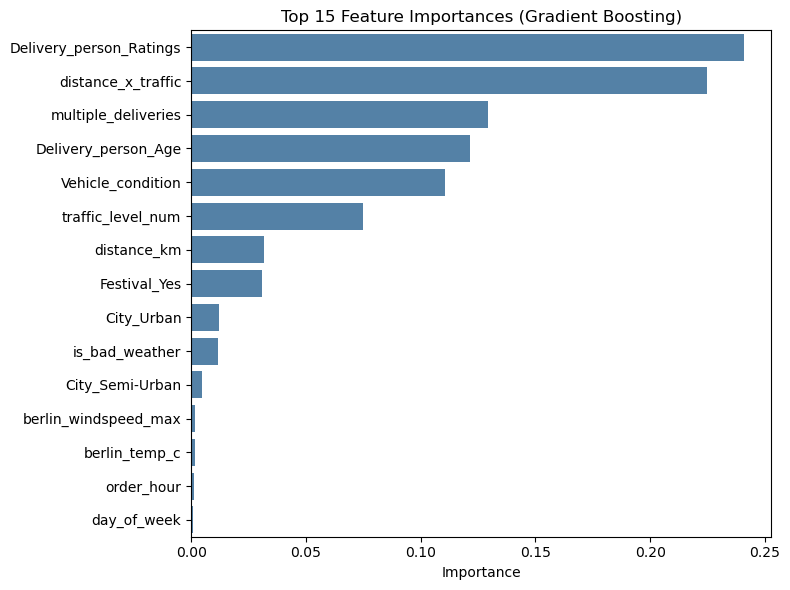

In [62]:
## Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', color='steelblue')
plt.title('Top 15 Feature Importances (Gradient Boosting)')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [63]:
final_results = pd.DataFrame(results).drop_duplicates(subset='model', keep='last').sort_values('R2', ascending=False)
print(final_results)

final_results.to_csv('model_comparison_baseline_vs_ensemble.csv', index=False)
print("Saved model comparison table")

               model       MAE      RMSE        R2
5  Gradient Boosting  4.216395  5.322884  0.676851
4      Random Forest  4.211176  5.324904  0.676606
1      Decision Tree  4.297159  5.455078  0.660601
0  Linear Regression  5.103365  6.442980  0.526541
Saved model comparison table


In [ ]:
### Feature Importance Takeaways

The top predictors align closely with patterns observed during EDA:

- **Delivery_person_Ratings** (0.241) is the single strongest predictor, consistent with 
  the -0.33 correlation and clear inverse trend seen in EDA — delivery person 
  experience/skill matters more than any other single factor.
      
- **distance_x_traffic** (0.225), the engineered interaction feature, ranks second — 
  notably higher than raw `distance_km` alone (0.032, ranked 7th). This confirms that 
  distance by itself is a weak predictor, but distance combined with traffic congestion 
  is highly predictive — validating the decision to engineer this interaction rather than 
  relying on the individual features.
      
- **multiple_deliveries** (0.129) ranks third, matching the clean monotonic relationship 
  with delivery time observed in EDA.
      
- **Delivery_person_Age** (0.122) and **Vehicle_condition** (0.110) both contribute 
  meaningfully, despite not being heavily emphasized in the EDA visuals.
      
- **Berlin weather features** (`berlin_windspeed_max`, `berlin_temp_c`, precipitation) rank 
  at the very bottom, with negligible importance. This is expected: since the delivery 
  records are not literally tied to real Berlin locations or dates, the enrichment 
  demonstrates the *technique* (external API integration, date-based merge) rather than 
  adding genuine predictive signal in this dataset. On truly location-matched data, weather 
  would likely show stronger importance, consistent with our EDA finding that weather 
  condition (Cloudy/Fog) correlated with longer delivery times.

In [ ]:
## Summary: Modeling (Baselines + Ensembles) Complete

- Trained and evaluated 4 models: Linear Regression, Decision Tree, Random Forest, 
  and Gradient Boosting.
      
- Ensembles clearly outperformed baselines, with Random Forest and Gradient Boosting 
  both reaching R² ≈ 0.677, compared to 0.661 (Decision Tree) and 0.527 (Linear Regression).
    
- Confirmed no meaningful overfitting for any model via train vs. validation comparison — 
  all models showed small, healthy train-validation gaps.
      
- Feature importance analysis validated key EDA hypotheses: delivery person rating, 
  the distance × traffic interaction, and multiple deliveries were the strongest predictors.
- Berlin weather enrichment showed minimal predictive power, an expected and honestly 
  reported limitation given the underlying data isn't literally Berlin-based — the 
  enrichment step demonstrates real-world data integration skills rather than adding 
  genuine model signal here.
      
- **Gradient Boosting selected for hyperparameter tuning**, given its comparable 
  performance to Random Forest and typically greater tuning headroom.

